# Analisis de placa radiocromica

Analisis de imagen para la placa radiocromica irradiada en el servicio de radioterapia de AUNA por un acelerador lineal cualesquiera.

El objetivo es detectar 5 puntos en la imagen, unir los puntos, trazar un cuadrado y hacer las siguientes mediciones:

- El FWHM cross-plane e in-plane.
- El desfase del cuadrado trazado respecto a los bordes del perfil al nivel de FWHM. (Para esto se podria usar el trazado de puntos, dibujar la linea, identificar el pixel en la region central, trazar los perfiles cross-plane e in-plane y segun este pixel fijar un posicion en este perfil y definir la posicion respecto a este punto en la curva con el pixel de referencia, definir la distancia entre los pixeles y hacer la conversion a longitud.)

In [1]:
import sys

print(sys.executable)
print(sys.version)

/home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/bin/python
3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]


## Librerias

In [2]:
import numpy as np
import scipy as sp
from scipy.fft import fft2
from scipy.fft import ifft2
from scipy.fft import fftfreq
from scipy.fft import fftshift, ifftshift
from scipy.signal import convolve2d

import imageio

import os
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import animation
from matplotlib.animation import PillowWriter
import pint

from PIL import Image

u = pint.UnitRegistry()

## Funciones auxiliares

In [3]:
def normalize_image(image):
    normalized_image = (image - np.min(image)) / (np.max(image) - np.min(image))
    return normalized_image

def intensidad_del_campo(campo):
    intensidad_espectro_imagen = np.abs(campo)**2
    return intensidad_espectro_imagen

### Placa a analizar

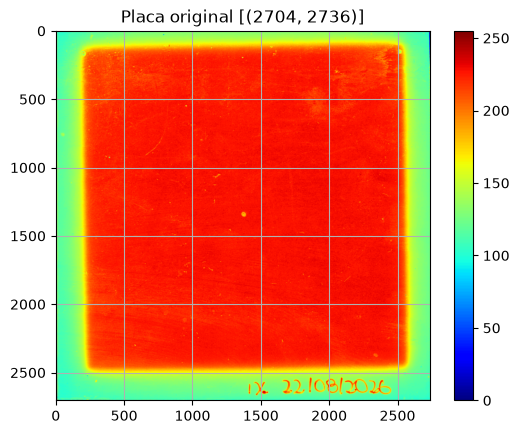

In [4]:
placa_analizada = cv2.bitwise_not(cv2.imread('/home/felipepp/Documents/CodigosPython/ImagenesDeReferencia/PlacasHistoricas/EPSON007.JPG', 0))

plt.imshow(placa_analizada, cmap = 'jet')
plt.title(f"Placa original [{np.shape(placa_analizada)}]")
plt.colorbar()
plt.grid()
plt.show()

## Perfiles Cross-plane e in-plane de la placa

In [5]:
print(np.shape(placa_analizada)[0])
print(np.shape(placa_analizada)[1])

2704
2736


Realizamos una operacion de aplicar un marco con valor cero en todo el borde con un grosor x, de tal forma que se eliminen los artefactos originados por la desalineacion de la placa con respecto al fondo y quede el blanco de la impresora al escanearse, por lo que esos valores terminan siendo valores extremos que alteran la medida y no aportan informacion.

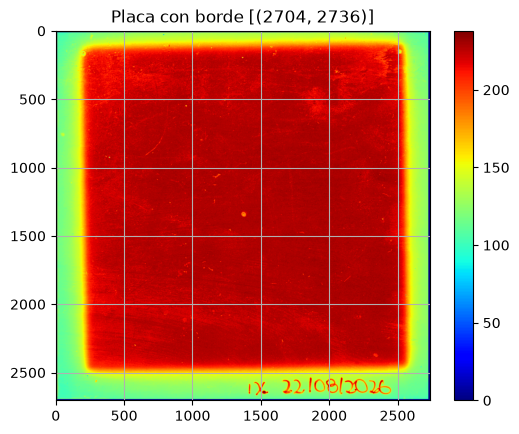

In [6]:
rectangulo_borde = cv2.rectangle(placa_analizada, (0, 0), (np.shape(placa_analizada)[1], np.shape(placa_analizada)[0]), 0, 20)

plt.imshow(rectangulo_borde, cmap = 'jet') # El grosor del rectangulo lo podemos dejar como una variable expuesta al usuario
plt.title(f"Placa con borde [{np.shape(rectangulo_borde)}]")
plt.colorbar()
plt.grid()
plt.show()

In [7]:
valor_pelicula_virgen = placa_analizada[int(np.shape(placa_analizada)[0]/2)][25] 
print(f"Valor de la película virgen: {valor_pelicula_virgen}") # La posicion de donde se extrae el valor de la placa virgen
                                                            # tambien se puede dejar expuesto al usuario, para mas precision
valor_cualquiera_zona_oscura = placa_analizada[int(np.shape(placa_analizada)[0]/2 - 50)][int(np.shape(placa_analizada)[1]/2 - 50)]
print(f"Valor de la zona oscura: {valor_cualquiera_zona_oscura}")

Valor de la película virgen: 117
Valor de la zona oscura: 228


Usamos una seccion lo suficientemente alejada de la region irradiada de la pelicula radiocromica que represente su estado virgen, de esta forma saber cual es el valor de referencia o cero de nuestra curva segun la intensidad que indica el color de la imagen. Ademas, normalizamos la imagen para que sea mas comodo al momento de manipularla y hacer operaciones con ella.

## Acondicionamiento de la imagen

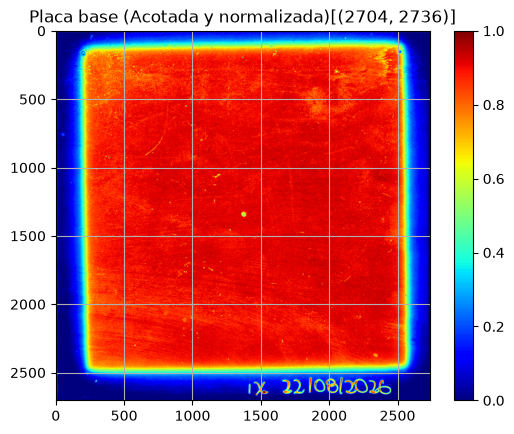

In [8]:
placa_recorte_borde = normalize_image( # Imagen base
    np.where(rectangulo_borde < valor_pelicula_virgen, valor_pelicula_virgen, rectangulo_borde))

placa_base = placa_recorte_borde.copy()

plt.imshow(placa_recorte_borde, cmap = 'jet')
plt.title(f"Placa base (Acotada y normalizada)[{np.shape(placa_recorte_borde)}]")
plt.colorbar()
plt.grid()
plt.show()

Puede implementarse una funcion que permita alternar el colormap de gray a jet para identificar facilmente donde quedan los puntos sin importar si se hacen con aguja o con marcador.

In [9]:
valor_pelicula_virgen = placa_recorte_borde[int(np.shape(placa_recorte_borde)[0]/2)][22]
print(f"Valor de la película virgen: {valor_pelicula_virgen}")

valor_cualquiera_zona_oscura = placa_recorte_borde[int(np.shape(placa_recorte_borde)[0]/2 - 50)][int(np.shape(placa_recorte_borde)[1]/2 - 50)]
print(f"Valor de la zona oscura: {valor_cualquiera_zona_oscura}")

Valor de la película virgen: 0.01652892561983471
Valor de la zona oscura: 0.9173553719008265


Con los valores ya normalizados y los artefactos de los bordes eliminados ya tenemos solo la curva de la zona de irradiacion en la imagen, ahora podemos saber cuales son los puntos maximos, definir el FWHM, pero ignorando otros artefactos que pueden coincidir con los planos de corte del analisis como el punto central que se traza debido a la proyeccion del crosshair en la pelicula, por esto y para no tener en cuenta la penumbra en el calculo de la media de la planicie de irradiacion, irgnoramos la region central, esto es aplicacble para este perfil que sale de un acelerador que si tiene filtro aplanador.

Media perfil cross-plane: 0.9130276370745579
Media perfil in-plane: 0.9035768239580555


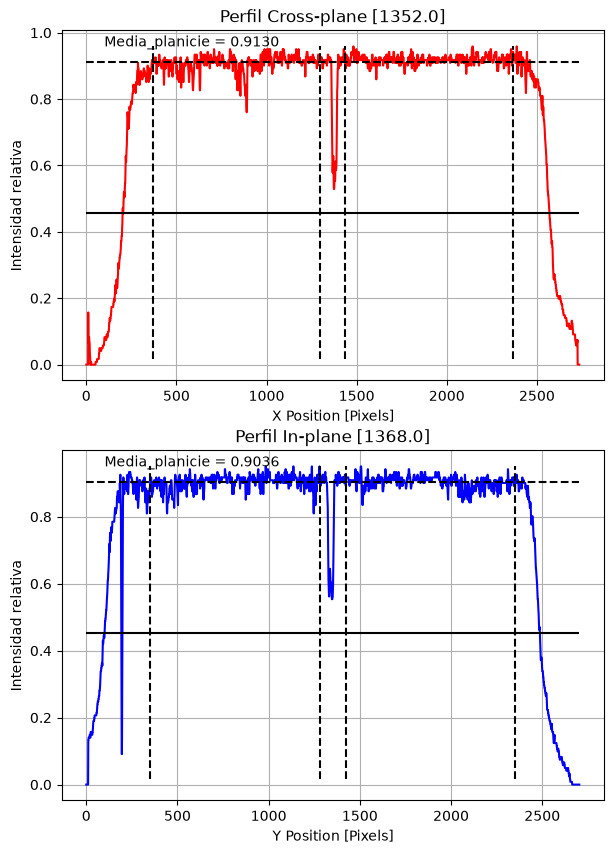

In [10]:
perfil_crossplane_borde = placa_recorte_borde[int(np.shape(placa_recorte_borde)[0]/2)]
perfil_inplane_borde = np.rot90(placa_recorte_borde)[int(np.shape(placa_recorte_borde)[1]/2)]

distancia_centro = 1000
ancho_ignorado = 70

media_crossplane_borde = (np.mean(
    perfil_crossplane_borde[int(np.shape(perfil_crossplane_borde)[0]/2)-distancia_centro:int(np.shape(perfil_crossplane_borde)[0]/2)-ancho_ignorado]) + np.mean(
        perfil_crossplane_borde[int(np.shape(perfil_crossplane_borde)[0]/2)+ancho_ignorado:int(np.shape(perfil_crossplane_borde)[0]/2)+distancia_centro]))/2

media_inplane_borde = (np.mean(
    perfil_inplane_borde[int(np.shape(perfil_inplane_borde)[0]/2)-distancia_centro:int(np.shape(perfil_inplane_borde)[0]/2)-ancho_ignorado]) + np.mean(
        perfil_inplane_borde[int(np.shape(perfil_inplane_borde)[0]/2)+ancho_ignorado:int(np.shape(perfil_inplane_borde)[0]/2)+distancia_centro]))/2
print(f"Media perfil cross-plane: {media_crossplane_borde}")
print(f"Media perfil in-plane: {media_inplane_borde}")

plt.figure(figsize = (7, 10))

plt.subplot(2, 1, 1)
plt.plot(perfil_crossplane_borde, color = 'red')
plt.hlines(media_crossplane_borde, xmin =0, xmax = np.shape(perfil_crossplane_borde)[0], color = 'black', linestyle = '--', label = f"Media planicie = {media_crossplane_borde:.2f}")

plt.hlines(media_crossplane_borde/2, xmin = 0, xmax = np.shape(perfil_crossplane_borde)[0], color = 'black', linestyle = '-', label = f"Media altura = {media_crossplane_borde/2:.2f}")

plt.vlines(int(np.shape(perfil_crossplane_borde)[0]/2)-ancho_ignorado, ymin = valor_pelicula_virgen, ymax = np.max(perfil_crossplane_borde), color = 'black', linestyle = '--')
plt.vlines(int(np.shape(perfil_crossplane_borde)[0]/2)+ancho_ignorado, ymin = valor_pelicula_virgen, ymax = np.max(perfil_crossplane_borde), color = 'black', linestyle = '--')
plt.vlines(int(np.shape(perfil_crossplane_borde)[0]/2)-distancia_centro, ymin = valor_pelicula_virgen, ymax = np.max(perfil_crossplane_borde), color = 'black', linestyle = '--')
plt.vlines(int(np.shape(perfil_crossplane_borde)[0]/2)+distancia_centro, ymin = valor_pelicula_virgen, ymax = np.max(perfil_crossplane_borde), color = 'black', linestyle = '--')
plt.text(100, np.max(perfil_crossplane_borde),
         f"Media_planicie = {media_crossplane_borde:.4f}",
         fontsize = 10, color = "black")

plt.grid()
plt.xlabel('X Position [Pixels]')
plt.ylabel('Intensidad relativa')
plt.title(f"Perfil Cross-plane [{np.shape(placa_recorte_borde)[0]/2}]")

plt.subplot(2, 1, 2)
plt.plot(perfil_inplane_borde, color = 'blue')
plt.hlines(media_inplane_borde, xmin = 0, xmax = np.shape(perfil_inplane_borde)[0], color = 'black', linestyle = '--', label = f"Media planicie = {media_inplane_borde:.2f}")

plt.hlines(media_inplane_borde/2, xmin = 0, xmax = np.shape(perfil_inplane_borde)[0], color = 'black', linestyle = '-', label = f"Media altura = {media_inplane_borde/2:.2f}")

plt.vlines(int(np.shape(perfil_inplane_borde)[0]/2)-ancho_ignorado, ymin = valor_pelicula_virgen, ymax = np.max(perfil_inplane_borde), color = 'black', linestyle = '--')
plt.vlines(int(np.shape(perfil_inplane_borde)[0]/2)+ancho_ignorado, ymin = valor_pelicula_virgen, ymax = np.max(perfil_inplane_borde), color = 'black', linestyle = '--')
plt.vlines(int(np.shape(perfil_inplane_borde)[0]/2)-distancia_centro, ymin = valor_pelicula_virgen, ymax = np.max(perfil_inplane_borde), color = 'black', linestyle = '--')
plt.vlines(int(np.shape(perfil_inplane_borde)[0]/2)+distancia_centro, ymin = valor_pelicula_virgen, ymax = np.max(perfil_inplane_borde), color = 'black', linestyle = '--')
plt.text(100, np.max(perfil_inplane_borde),
         f"Media_planicie = {media_inplane_borde:.4f}",
         fontsize = 10, color = "black")

plt.grid()
plt.xlabel('Y Position [Pixels]')
plt.ylabel('Intensidad relativa')
plt.title(f"Perfil In-plane [{np.shape(placa_recorte_borde)[1]/2}]")
plt.show()

Se puede agregar a la lista de variables expuestas la posicion y ancho de la zona de exclusion, en caso de que aparezcan artefactos, o... debemos hacer un suavizado mejor, luego de definir la media, claro.

Segun las secciones delimitadas, determinamos la cercania del punto a la mitad de la altura, el FWHM, que en este caso es la media/2, por esto fue importante hallar la media y acondicionar la imagen, y extraemos el pixel y el valor de la posicion que queda con la menor diferencia respecto al valor a media altura.

In [11]:
indice_corte_1c = (np.abs(perfil_crossplane_borde[0:int(np.shape(perfil_crossplane_borde)[0]/2) - ancho_ignorado] - media_crossplane_borde/2)).argmin()
indice_corte_2c = (np.abs(perfil_crossplane_borde[int(np.shape(perfil_crossplane_borde)[0]/2) + ancho_ignorado:] - media_crossplane_borde/2)).argmin() + int(np.shape(perfil_crossplane_borde)[0]/2) + ancho_ignorado
print(f"Indice de corte crossplane: {indice_corte_1c} px")
print(f"Indice de corte 2 crossplane: {indice_corte_2c} px")

print(f"Valor de corte 1 crossplane: {perfil_crossplane_borde[indice_corte_1c]}")
print(f"Valor de corte 2 crossplane: {perfil_crossplane_borde[indice_corte_2c]}")

indice_corte_1i = (np.abs(perfil_inplane_borde[0:int(np.shape(perfil_inplane_borde)[0]/2) - ancho_ignorado] - media_inplane_borde/2)).argmin()
indice_corte_2i = (np.abs(perfil_inplane_borde[int(np.shape(perfil_inplane_borde)[0]/2) + ancho_ignorado:] - media_inplane_borde/2)).argmin() + int(np.shape(perfil_inplane_borde)[0]/2) + ancho_ignorado
print(f"Indice de corte 1 inplane: {indice_corte_1i} px")
print(f"Indice de corte 2 inplane: {indice_corte_2i} px")

print(f"Valor de corte 1 inplane: {perfil_inplane_borde[indice_corte_1i]}")
print(f"Valor de corte 2 inplane: {perfil_inplane_borde[indice_corte_2i]}")

Indice de corte crossplane: 204 px
Indice de corte 2 crossplane: 2569 px
Valor de corte 1 crossplane: 0.45454545454545453
Valor de corte 2 crossplane: 0.4628099173553719
Indice de corte 1 inplane: 96 px
Indice de corte 2 inplane: 2487 px
Valor de corte 1 inplane: 0.4462809917355372
Valor de corte 2 inplane: 0.45454545454545453


Claro, si le estamos quitando la mitad y necesitamos es saber el indice del pixel absoluto tenemos que volver a agregarle la mitad de la cantidad de pixeles que le quitamos luego de haber encontrado el punto de interes en esa region delimitada, y como tambien le quitamos una pequena zona central, tambien se la debemos agregar, como en la primera no importa cuanto le quitemos la posicion absoluta coincide con la relativa, no le debemos agregar nada, puede esto cambiar?

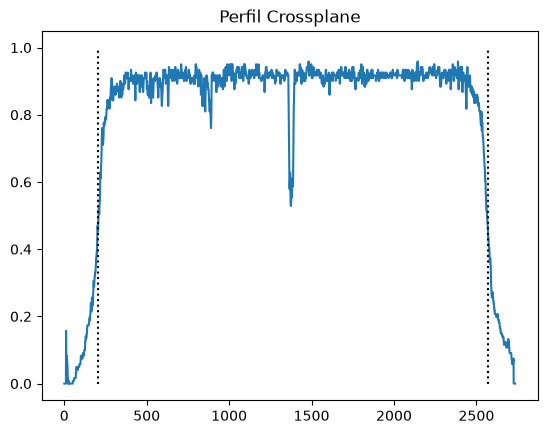

In [12]:
plt.plot(perfil_crossplane_borde)
plt.vlines(indice_corte_1c, 0, 1, color = 'black', linestyles = ':')
plt.vlines(indice_corte_2c, 0, 1, color = 'black', linestyles = ':')
plt.title('Perfil Crossplane')
plt.show()

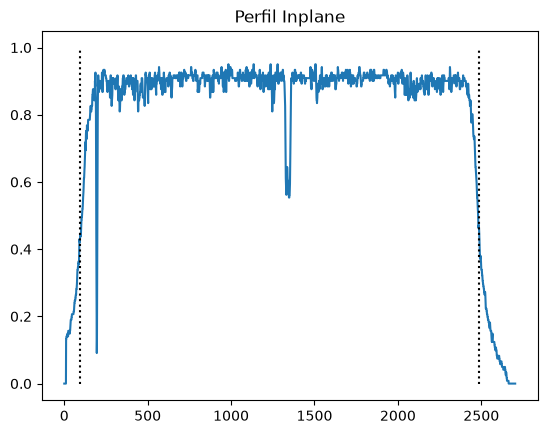

In [13]:
plt.plot(perfil_inplane_borde)
plt.vlines(indice_corte_1i, 0, 1, color = 'black', linestyles = ':')
plt.vlines(indice_corte_2i, 0, 1, color = 'black', linestyles = ':')
plt.title('Perfil Inplane')
plt.show()

Simplemente debemos conocer la resolucion del escaneo y conociendo la distancia entre pixeles podemos obtener la distancia entre los dos valores de cada punto de corte obtenemos el ancho a media altura.

In [14]:
tamano_pixel = 25.4/600 # Cuando es escaneada a 600 dpi

FWHM_crossplane = (indice_corte_2c - indice_corte_1c) * tamano_pixel
FWHM_inplane = (indice_corte_2i - indice_corte_1i) * tamano_pixel

print(f"FWHM crossplane: {np.round(FWHM_crossplane, 3)} mm")
print(f"FWHM inplane: {np.round(FWHM_inplane, 3)} mm")

FWHM crossplane: 100.118 mm
FWHM inplane: 101.219 mm


### Trazado de los bordes del campo luminoso

QFontDatabase: Cannot find font directory /home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no long

Puntos guardados (coordenadas [x, y]): [(196, 163), (2515, 151), (2551, 2507), (1374, 1335), (233, 2520)]


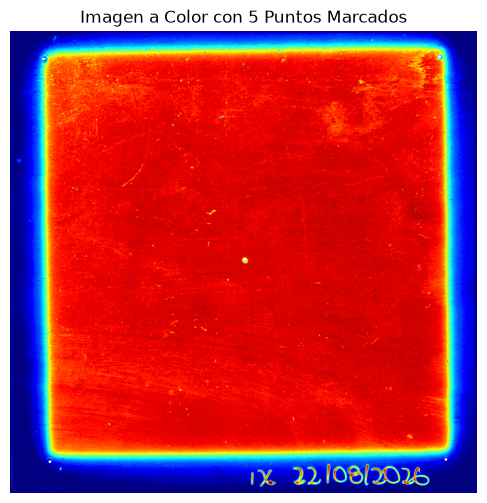

In [15]:
# --- 1. Aplicar mapa de color a la imagen base ---
# Convertimos el float32 [0.0, 1.0] a uint8 [0, 255] para aplicar el mapa de color de OpenCV
img_uint8 = (placa_recorte_borde * 255).clip(0, 255).astype(np.uint8)

# Aplicar mapa de color (Puedes cambiar cv2.COLORMAP_JET por:
# COLORMAP_VIRIDIS, COLORMAP_HOT, COLORMAP_TURBO, COLORMAP_PLASMA, COLORMAP_BONE)
placa_color_bgr = cv2.applyColorMap(img_uint8, cv2.COLORMAP_JET)

# Convertir de vuelta a float32 [0.0, 1.0] para trabajar uniformemente
placa_color = placa_color_bgr.astype(np.float32) / 255.0

puntos = []


def seleccionar_puntos(event, x, y, flags, param):
    global puntos, placa_color

    if event == cv2.EVENT_LBUTTONDOWN and len(puntos) < 5:
        puntos.append((x, y))

        # Dibujar punto con intensidad de contraste sobre el mapa de calor
        # (1.0, 1.0, 1.0) = Blanco puro | (0.0, 0.0, 0.0) = Negro puro
        cv2.circle(placa_color, (x, y), 8, (1.0, 1.0, 1.0), -1)


# --- 2. Interfaz interactiva OpenCV ---
cv2.namedWindow("Seleccionar 5 Puntos", cv2.WINDOW_NORMAL)
cv2.setMouseCallback("Seleccionar 5 Puntos", seleccionar_puntos)
cv2.resizeWindow("Seleccionar 5 Puntos", 1280, 720)

while True:
    cv2.imshow("Seleccionar 5 Puntos", placa_color)

    key = cv2.waitKey(1) & 0xFF
    if key == 27 or len(puntos) == 5:
        if len(puntos) == 5:
            cv2.imshow("Seleccionar 5 Puntos", placa_color)
            cv2.waitKey(300)
        break

cv2.destroyAllWindows()
cv2.waitKey(1)

# --- 3. Renderizado inline dentro del Notebook ---
print(f"Puntos guardados (coordenadas [x, y]): {puntos}")

# Convertir BGR a RGB para mostrar exactamente lo mismo en Matplotlib
placa_color_rgb = cv2.cvtColor(
    (placa_color * 255).astype(np.uint8), cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 6))
plt.imshow(placa_color_rgb)
plt.title("Imagen a Color con 5 Puntos Marcados")
plt.axis("off")
plt.show()

Utilizamos una funcion que nos permite dibujar sobre la imagen 4 puntos, posteriormente debemos dibujar 5 para tener en cuenta el centro.

In [16]:
type(placa_recorte_borde)

numpy.ndarray

Detectamos un punto por cuadrante pero si queremos obtener el punto central debemos definir una region mas de deteccion, en la cual si las coordenadas de ese punto lo detectan ahi entonces es el punto central.

In [17]:
for i in puntos: # Podemos dejar el ancho de la region central tambien como una variable expuesta la usuario
    if  (int(np.shape(placa_recorte_borde)[0]//2) - 100) < int(i[0]) < (int(np.shape(placa_recorte_borde)[0]//2) + 100) and (int(np.shape(placa_recorte_borde)[1]//2) - 100) < int(i[1]) < (int(np.shape(placa_recorte_borde)[1]//2) + 100):
        punto_CC = i
    else:
        if int(i[0]) < int(np.shape(placa_recorte_borde)[0]//2):
            # Region horizontal a la izquiera
            if int(i[1]) > int(np.shape(placa_recorte_borde)[1]//2):
                punto_DL = i
            else:
                punto_UL = i
        else:
            # Region horizontal a la derecha
            if int(i[1]) > int(np.shape(placa_recorte_borde)[1]//2):
                punto_DR = i
            else:
                punto_UR = i

print(f"Coordenada arriba izquierda: {punto_UL}")
print(f"Coordenada arriba derecha: {punto_UR}")
print(f"Coordenada abajo izquierda: {punto_DL}")
print(f"Coordenada abajo derecha: {punto_DR}")
print(f"Coordenada punto central {punto_CC}")

Coordenada arriba izquierda: (196, 163)
Coordenada arriba derecha: (2515, 151)
Coordenada abajo izquierda: (233, 2520)
Coordenada abajo derecha: (2551, 2507)
Coordenada punto central (1374, 1335)


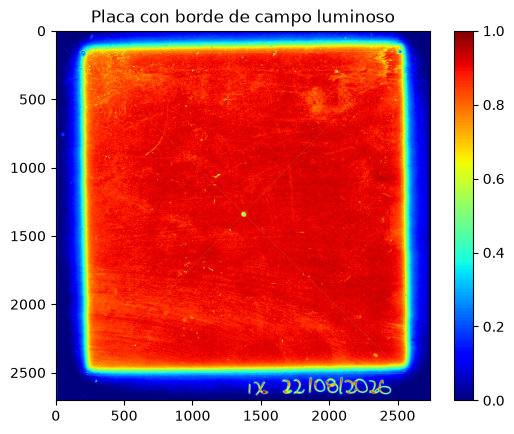

In [18]:
valor_trazos = float((media_crossplane_borde + media_inplane_borde)/4)
grosor_trazo = 1

cv2.line(placa_recorte_borde, punto_UL, punto_UR, valor_trazos, grosor_trazo)
cv2.line(placa_recorte_borde, punto_UL, punto_DL, valor_trazos, grosor_trazo)
cv2.line(placa_recorte_borde, punto_UL, punto_DR, valor_trazos, grosor_trazo)
cv2.line(placa_recorte_borde, punto_DL, punto_UR, valor_trazos, grosor_trazo)
cv2.line(placa_recorte_borde, punto_UR, punto_DR, valor_trazos, grosor_trazo)
cv2.line(placa_recorte_borde, punto_DL, punto_DR, valor_trazos, grosor_trazo)

plt.imshow(placa_recorte_borde, cmap = 'jet')
plt.title("Placa con borde de campo luminoso")
plt.colorbar()
plt.show()

## Separando los campos

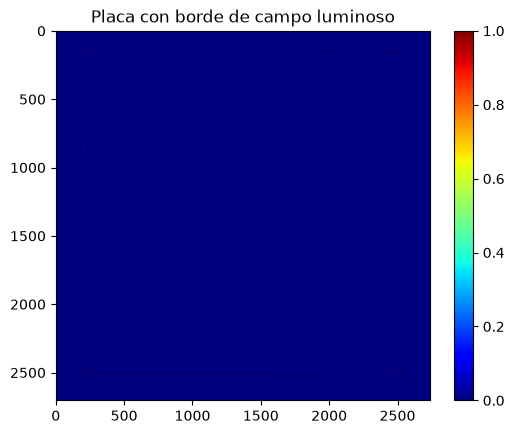

In [19]:
fondo = np.zeros(np.shape(placa_analizada))

valor_trazos = 1
grosor_trazo = 1

cv2.line(fondo, punto_UL, punto_UR, valor_trazos, grosor_trazo)
cv2.line(fondo, punto_UL, punto_DL, valor_trazos, grosor_trazo)
cv2.line(fondo, punto_UL, punto_DR, valor_trazos, grosor_trazo)
cv2.line(fondo, punto_DL, punto_UR, valor_trazos, grosor_trazo)
cv2.line(fondo, punto_UR, punto_DR, valor_trazos, grosor_trazo)
cv2.line(fondo, punto_DL, punto_DR, valor_trazos, grosor_trazo)

plt.imshow(fondo, cmap = 'jet')
plt.title("Placa con borde de campo luminoso")
plt.colorbar()
plt.show()

Probaremos un metodo grafico mas limpio para encontrar los puntos donde el crossplane cruza las lineas trazadas por los puntos del campo luminoso, ya que en esta imagen anterior tenemos solo los trazos en un fondo cero.

In [20]:
perfil_crossplane_campo_luminoso = fondo[int(np.shape(fondo)[0]/2)]
perfil_inplane_campo_luminoso = np.rot90(fondo)[int(np.shape(fondo)[1]/2)]

px_trazo_cl_izq = (np.abs(perfil_crossplane_campo_luminoso[0:int(np.shape(perfil_crossplane_campo_luminoso)[0]/2) - ancho_ignorado] - 1)).argmin()
px_trazo_cl_der = (np.abs(perfil_crossplane_campo_luminoso[int(np.shape(perfil_crossplane_campo_luminoso)[0]/2) + ancho_ignorado:] - 1)).argmin() + int(np.shape(perfil_crossplane_campo_luminoso)[0]/2) + ancho_ignorado

diff_cl_L = (px_trazo_cl_izq - indice_corte_1c) * tamano_pixel
diff_cl_R = (px_trazo_cl_der - indice_corte_2c) * tamano_pixel

print(f"Pixel cruce linea izquierda: {px_trazo_cl_izq} px")
print(f"Pixel cruce linea derecha: {px_trazo_cl_der} px")

print(f"Desfase en el lado izquierdo de la placa: {np.round(diff_cl_L*tamano_pixel, 4)} mm")
print(f"Desfase en el lado derecho de la placa: {np.round(diff_cl_R*tamano_pixel, 4)} mm")

Pixel cruce linea izquierda: 215 px
Pixel cruce linea derecha: 2533 px
Desfase en el lado izquierdo de la placa: 0.0197 mm
Desfase en el lado derecho de la placa: -0.0645 mm


Se debe ignorar la region central nuevamente debido a la interseccion de las rectas, puesto que estas entran tambien dentro de los valores que cumplen en alguna de las regiones a analizar.

In [21]:
perfil_crossplane_campo_luminoso = fondo[int(np.shape(fondo)[0]/2)] # Considero mucho mejor este metodo
perfil_inplane_campo_luminoso = np.rot90(fondo)[int(np.shape(fondo)[1]/2)]

px_trazo_cl_izq = np.where(perfil_crossplane_campo_luminoso[0:int(np.shape(perfil_crossplane_campo_luminoso)[0]/2) - ancho_ignorado] == 1)[0].item()
px_trazo_cl_der = np.where(perfil_crossplane_campo_luminoso[int(np.shape(perfil_crossplane_campo_luminoso)[0]/2) + ancho_ignorado:] == 1)[0].item() + int(np.shape(perfil_crossplane_campo_luminoso)[0]/2) + ancho_ignorado

diff_cl_L = (px_trazo_cl_izq - indice_corte_1c) * tamano_pixel
diff_cl_R = (px_trazo_cl_der - indice_corte_2c) * tamano_pixel

print(f"Pixel cruce linea izquierda: {px_trazo_cl_izq} px")
print(f"Pixel cruce linea derecha: {px_trazo_cl_der} px")

print(f"Desfase en el lado izquierdo de la placa: {np.round(diff_cl_L*tamano_pixel, 4)} mm")
print(f"Desfase en el lado derecho de la placa: {np.round(diff_cl_R*tamano_pixel, 4)} mm")

px_trazo_cl_arr = np.where(perfil_inplane_campo_luminoso[0:int(np.shape(perfil_inplane_campo_luminoso)[0]/2) - ancho_ignorado] == 1)[0].item()
px_trazo_cl_aba = np.where(perfil_inplane_campo_luminoso[int(np.shape(perfil_inplane_campo_luminoso)[0]/2) + ancho_ignorado:] == 1)[0].item() + int(np.shape(perfil_inplane_campo_luminoso)[0]/2) + ancho_ignorado

diff_cl_U = (px_trazo_cl_arr - indice_corte_1i) * tamano_pixel
diff_cl_D = (px_trazo_cl_aba - indice_corte_2i) * tamano_pixel

print(f"Pixel cruce linea arriba: {px_trazo_cl_arr} px")
print(f"Pixel cruce linea abajo: {px_trazo_cl_aba} px")

print(f"Desfase en el lado arriba de la placa: {np.round(diff_cl_U*tamano_pixel, 4)} mm")
print(f"Desfase en el lado abajo de la placa: {np.round(diff_cl_D*tamano_pixel, 4)} mm")

Pixel cruce linea izquierda: 215 px
Pixel cruce linea derecha: 2533 px
Desfase en el lado izquierdo de la placa: 0.0197 mm
Desfase en el lado derecho de la placa: -0.0645 mm
Pixel cruce linea arriba: 157 px
Pixel cruce linea abajo: 2514 px
Desfase en el lado arriba de la placa: 0.1093 mm
Desfase en el lado abajo de la placa: 0.0484 mm


El signo de cada uno tiene significado, si la resta es px_trazo - px_ FWHM y conociendo la orientacion de los ejes, con x hacia la derecha y y hacia abajo, que si nos da negativo horizontalmente es que la FWMH es mayor, esta mas a la derecha. Y si verticalmente nos da negativo, es porque la FWHM es mayor tambien pero significa que esta mas hacia abajo que el punto por donde pasa el trazo.

Debe ser natural y correcto preferir la separacion de los campos para detectar el trazado, que nuevamente puede ser un modelo grafico o aritmetico como el del centro, que analizar completamente el perfil con la curva incluso sabiendo que el trazado de las lineas es unicamente para identificar la posicion donde la linea cruza el punto de corte de cada perfil, asi que para esto no necesitamos realmente la curva, luego con el valor obtenido facilmente obtenemos ls diferencia con respecto a la posicion del punto que coincide con la media altura, diferente en este caso pues para el FWHM si necesitamos directamente el cruce frente a la curva.

In [22]:
perfil_crossplane_borde = placa_recorte_borde[int(np.shape(placa_recorte_borde)[0]/2)]
perfil_inplane_borde = np.rot90(placa_recorte_borde)[int(np.shape(placa_recorte_borde)[1]/2)]

px_trazo_izq = (np.abs(perfil_crossplane_borde[0:int(np.shape(perfil_crossplane_borde)[0]/2) - ancho_ignorado] - media_crossplane_borde/2)).argmin()
px_trazo_der = (np.abs(perfil_crossplane_borde[int(np.shape(perfil_crossplane_borde)[0]/2) + ancho_ignorado:] - media_crossplane_borde/2)).argmin() + int(np.shape(perfil_crossplane_borde)[0]/2) + ancho_ignorado

diff_L = (px_trazo_izq - indice_corte_1c) * tamano_pixel
diff_R = (px_trazo_der - indice_corte_2c) * tamano_pixel

print(f"Desfase en el lado izquierdo de la placa: {np.round(diff_L*tamano_pixel, 4)} mm")
print(f"Desfase en el lado derecho de la placa: {np.round(diff_R*tamano_pixel, 4)} mm")

Desfase en el lado izquierdo de la placa: 0.0 mm
Desfase en el lado derecho de la placa: -0.0645 mm


Ahora debemos encontrar el desfase del punto central, indicado por el centro del crosshair frente al trazado por el centro del cuadritalero. Vamos a probar el metodo matematico de interceptacion de las rectas trazadas por los puntos, aproximando al pixel mas cercano.

In [23]:
# Puntos diagonal 1: Arriba izquierda y abajo derecha
# Pendiente diagonal 1:
m_1 = (punto_DR[1] - punto_UL[1])/(punto_DR[0] - punto_UL[0])

# Puntos diagonal 2: Arriba derecha y abajo izquierda
# Pendiente diagonale 2:
m_2 = (punto_UR[1] - punto_DL[1])/(punto_UR[0] - punto_DL[0])

# Puntos de interseccion de cada diagonal con el eje y
b_1 = punto_DR[1] - punto_DR[0] * m_1
b_2 = punto_UR[1] - punto_UR[0] * m_2

x_0 = (b_2 - b_1)/(m_1 - m_2) # Resolviendo igualando las rectas en y

y_0 = m_1 * x_0 + b_1 # Punto en y para el valor de x hallado

print(f"El punto de interseccion de las rectas esta en: ({int(np.round(x_0, 0))}, {int(np.round(y_0, 0))})")

# Ahora debemos calcular la distancia por coordenada:
desfase_cx = (punto_CC[0] - x_0) * tamano_pixel
desfase_cy = (punto_CC[1] - y_0) * tamano_pixel

print(f"Desfase de centro en crossplane: {np.round(desfase_cx, 3)} mm")
print(f"Desfase de centro en inplane: {np.round(desfase_cy, 3)} mm")

El punto de interseccion de las rectas esta en: (1374, 1335)
Desfase de centro en crossplane: -0.0 mm
Desfase de centro en inplane: -0.021 mm


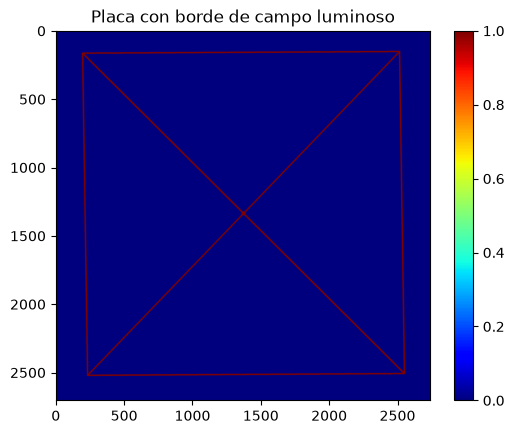

In [24]:
fondo = np.zeros(np.shape(placa_analizada))

valor_trazos = 1
grosor_trazo = 10

cv2.line(fondo, punto_UL, punto_UR, valor_trazos, grosor_trazo)
cv2.line(fondo, punto_UL, punto_DL, valor_trazos, grosor_trazo)
cv2.line(fondo, punto_UL, punto_DR, valor_trazos, grosor_trazo)
cv2.line(fondo, punto_DL, punto_UR, valor_trazos, grosor_trazo)
cv2.line(fondo, punto_UR, punto_DR, valor_trazos, grosor_trazo)
cv2.line(fondo, punto_DL, punto_DR, valor_trazos, grosor_trazo)

cv2.circle(fondo, (int(np.round(x_0, 0)), int(np.round(y_0, 0))), 15, color = 1, thickness = -1)
cv2.circle(fondo, punto_CC, 15, color = 1, thickness = -1)

plt.imshow(fondo, cmap = 'jet')
plt.title("Placa con borde de campo luminoso")
plt.colorbar()
plt.show()

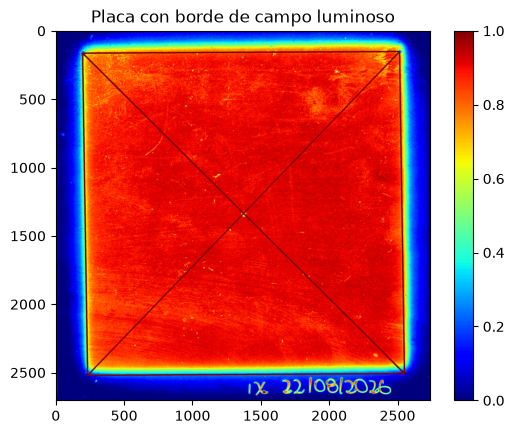

In [25]:
valor_trazos = 1
grosor_trazo = 10

cv2.line(placa_recorte_borde, punto_UL, punto_UR, valor_trazos, grosor_trazo)
cv2.line(placa_recorte_borde, punto_UL, punto_DL, valor_trazos, grosor_trazo)
cv2.line(placa_recorte_borde, punto_UL, punto_DR, valor_trazos, grosor_trazo)
cv2.line(placa_recorte_borde, punto_DL, punto_UR, valor_trazos, grosor_trazo)
cv2.line(placa_recorte_borde, punto_UR, punto_DR, valor_trazos, grosor_trazo)
cv2.line(placa_recorte_borde, punto_DL, punto_DR, valor_trazos, grosor_trazo)

plt.imshow(placa_recorte_borde, cmap = 'jet')
plt.title("Placa con borde de campo luminoso")
plt.colorbar()
plt.show()

# Analisis placa RGB

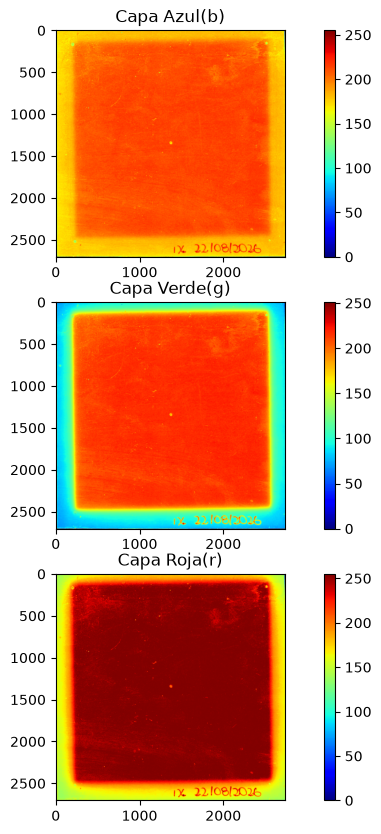

In [26]:
placa_analizada_rgb = cv2.bitwise_not(cv2.imread('/home/felipepp/Documents/CodigosPython/ImagenesDeReferencia/PlacasHistoricas/EPSON007.JPG', 1))

b, g, r = cv2.split(placa_analizada_rgb)

plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.imshow(b, cmap = 'jet')
plt.colorbar()
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.imshow(g, cmap = 'jet')
plt.colorbar()
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3) # Numero filas, columnas, posicion especifica.
plt.imshow(r, cmap = 'jet')
plt.colorbar()
plt.title('Capa Roja(r)')

plt.show()

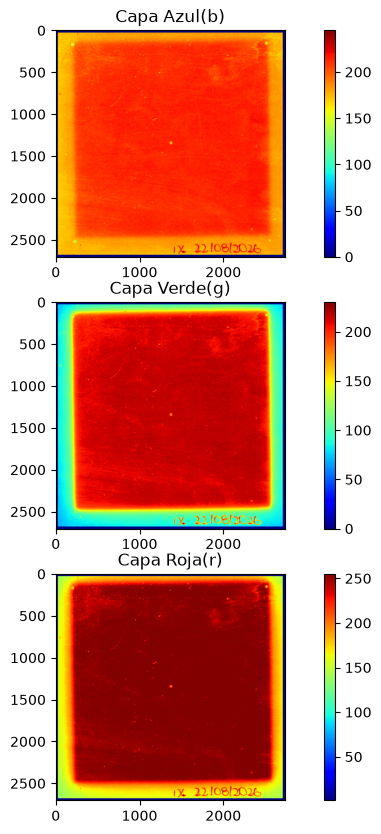

In [27]:
grosor_marco = 50

rectangulo_borde_b = cv2.rectangle(b, (0, 0), (np.shape(b)[1], np.shape(b)[0]), 0, grosor_marco)
rectangulo_borde_g = cv2.rectangle(g, (0, 0), (np.shape(g)[1], np.shape(g)[0]), 1, grosor_marco)
rectangulo_borde_r = cv2.rectangle(r, (0, 0), (np.shape(r)[1], np.shape(r)[0]), 1, grosor_marco)

plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.imshow(rectangulo_borde_b, cmap = 'jet')
plt.colorbar()
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.imshow(rectangulo_borde_g, cmap = 'jet')
plt.colorbar()
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3)
plt.imshow(rectangulo_borde_r, cmap = 'jet')
plt.colorbar()
plt.title('Capa Roja(r)')

plt.show()

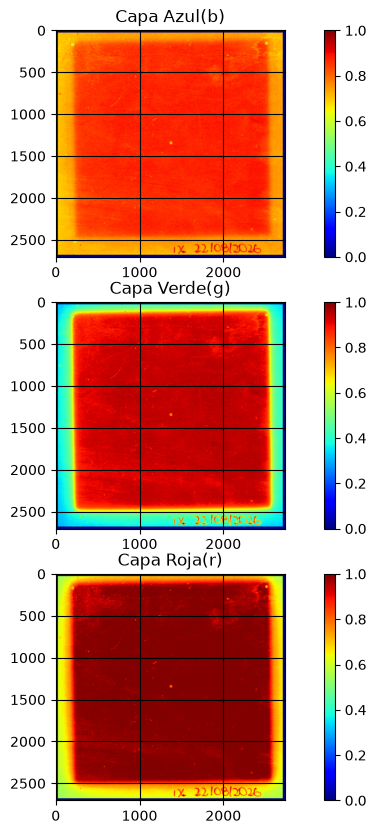

In [28]:
placa_recorte_borde_b = normalize_image(rectangulo_borde_b)
placa_recorte_borde_g = normalize_image(rectangulo_borde_g)
placa_recorte_borde_r = normalize_image(rectangulo_borde_r)


plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.imshow(placa_recorte_borde_b, cmap = 'jet')
plt.colorbar()
plt.grid(True, color = 'black')
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.imshow(placa_recorte_borde_g, cmap = 'jet')
plt.colorbar()
plt.grid(True, color = 'black')
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3)
plt.imshow(placa_recorte_borde_r, cmap = 'jet')
plt.colorbar()
plt.grid(True, color = 'black')
plt.title('Capa Roja(r)')

plt.show()
